In [10]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, GroupKFold

In [2]:
# 1. 데이터 전처리

BASE_DIR = r'C:\Projects\ML\Dataset\35Hz12kN' 

# 경로 점검 (문제 있으면 바로 보이게)
subdirs = sorted([d for d in os.listdir(BASE_DIR)
                  if os.path.isdir(os.path.join(BASE_DIR, d))])
print("bearing folder:", subdirs)
first = os.path.join(BASE_DIR, subdirs[0])
print(f"{subdirs[0]} file quantity:",
      len([f for f in os.listdir(first) if f.endswith('.csv')]))

# features 추출
def extract_features(sig):
    s = pd.Series(sig)
    rms  = np.sqrt(np.mean(sig**2))
    peak = np.max(np.abs(sig))
    return {
        'mean_abs': np.mean(np.abs(sig)),
        'std':      np.std(sig),
        'rms':      rms,
        'peak':     peak,
        'kurt':     s.kurt(),
        'skew':     s.skew(),
        'crest':    peak / rms if rms > 0 else 0,
    }

# 모든 스냅샷 → 한 줄씩 쌓기
rows = []
for b in subdirs:
    bdir = os.path.join(BASE_DIR, b)
    files = [f for f in os.listdir(bdir) if f.endswith('.csv')]
    files = sorted(files, key=lambda f: int(os.path.splitext(f)[0]))  # 숫자순
    N = len(files)                       # 이 베어링 총수명(분)

    for f in files:
        i = int(os.path.splitext(f)[0])  # 경과시간(분)
        snap = pd.read_csv(os.path.join(bdir, f))
        h = snap.iloc[:, 0].values       # 수평 진동
        v = snap.iloc[:, 1].values       # 수직 진동

        hf = extract_features(h)
        vf = extract_features(v)
        row = {'bearing': b, 'op_minute': i, 'RUL': N - i}
        row.update({f'h_{k}': val for k, val in hf.items()})
        row.update({f'v_{k}': val for k, val in vf.items()})
        rows.append(row)
    print(f"{b}: 총수명 {N}분 처리 완료")

df = pd.DataFrame(rows)
df.to_csv('features.csv', index=False, encoding='utf-8-sig')

print("\n=== 완료 ===")
print("features.csv shape:", df.shape)
print(df['bearing'].value_counts())
print(df.head())

bearing folder: ['Bearing1', 'Bearing2', 'Bearing3', 'Bearing4', 'Bearing5']
Bearing1 file quantity: 123
Bearing1: 총수명 123분 처리 완료
Bearing2: 총수명 161분 처리 완료
Bearing3: 총수명 158분 처리 완료
Bearing4: 총수명 122분 처리 완료
Bearing5: 총수명 52분 처리 완료

=== 완료 ===
features.csv shape: (616, 17)
bearing
Bearing2    161
Bearing3    158
Bearing1    123
Bearing4    122
Bearing5     52
Name: count, dtype: int64
    bearing  op_minute  RUL  h_mean_abs     h_std     h_rms    h_peak  \
0  Bearing1          1  122    0.449234  0.563842  0.563890  2.529883   
1  Bearing1          2  121    0.469337  0.589026  0.589078  3.623104   
2  Bearing1          3  120    0.469207  0.589534  0.589536  3.321779   
3  Bearing1          4  119    0.473610  0.597236  0.597274  2.872622   
4  Bearing1          5  118    0.479684  0.604520  0.604645  4.136920   

     h_kurt    h_skew   h_crest  v_mean_abs     v_std     v_rms    v_peak  \
0  0.071546 -0.001797  4.486485    0.447903  0.560470  0.560471  2.469349   
1  0.138146 -0.014992 

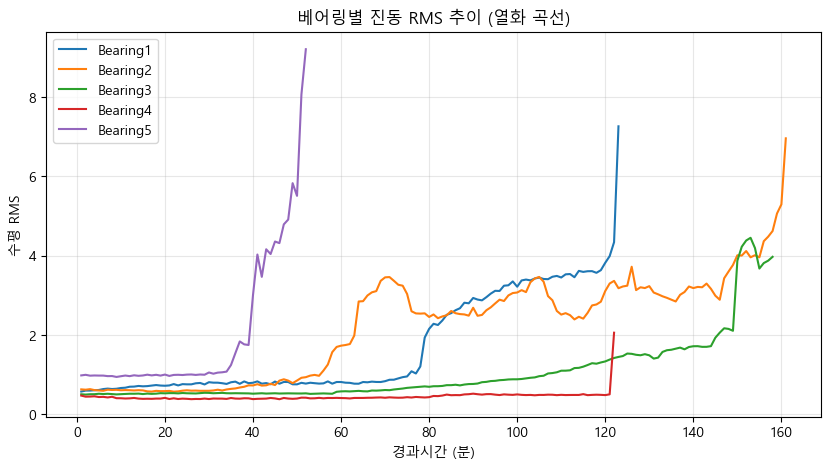

In [3]:
# 2. 데이터 로드(features.csv)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('features.csv')

# 베어링별 RMS가 시간 따라 오르는지 (열화 신호 확인)
plt.figure(figsize=(10, 5))
for b, g in df.groupby('bearing'):
    plt.plot(g['op_minute'], g['h_rms'], label=b)
plt.xlabel('경과시간 (분)')
plt.ylabel('수평 RMS')
plt.title('베어링별 진동 RMS 추이 (열화 곡선)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

베어링별 초기 RMS 기준선:
 bearing
Bearing1    0.613
Bearing2    0.606
Bearing3    0.499
Bearing4    0.428
Bearing5    0.963
Name: h_rms, dtype: float64 



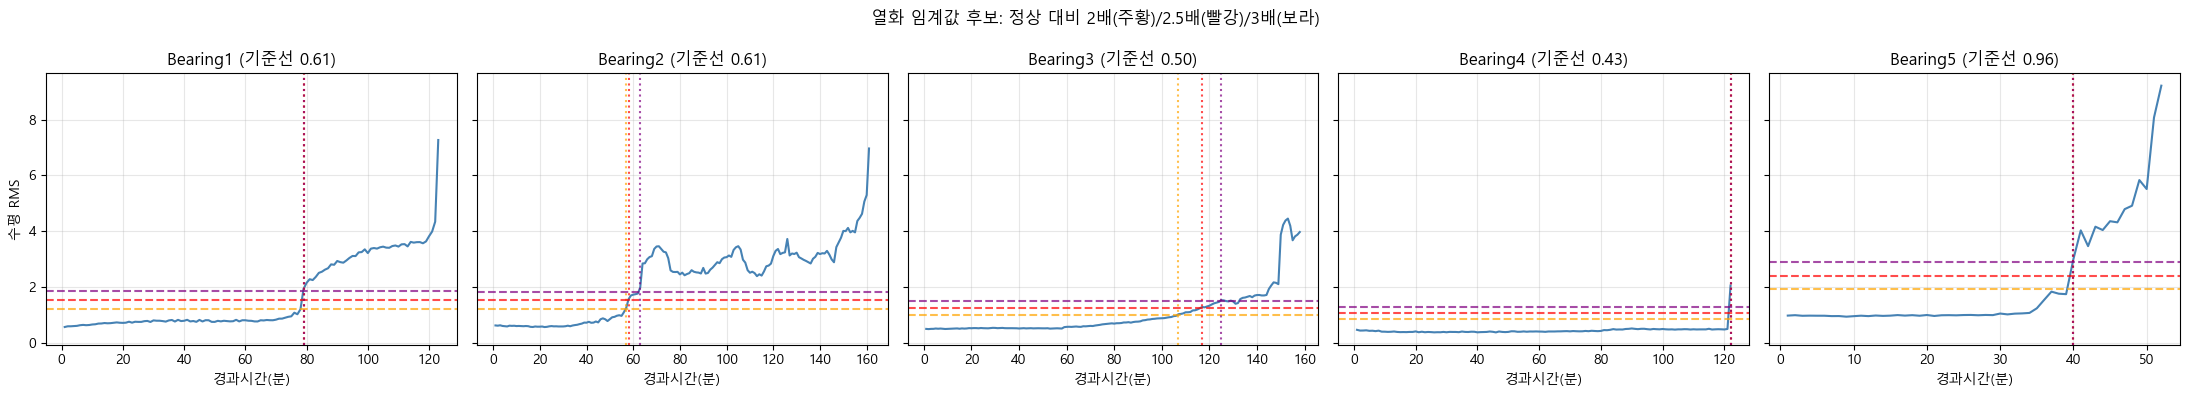

In [4]:
# 3. 열화 라벨 기준 정하기 — RMS 배수 임계값 후보 비교

# 각 베어링의 '초기 정상상태' = 처음 10분 RMS 평균
baseline = df[df['op_minute'] <= 10].groupby('bearing')['h_rms'].mean()
print("베어링별 초기 RMS 기준선:\n", baseline.round(3), "\n")

# 배수 후보 (정상 대비 2배 / 2.5배 / 3배)
multipliers = [2.0, 2.5, 3.0]

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)
for ax, (b, g) in zip(axes, df.groupby('bearing')):
    g = g.sort_values('op_minute')
    base = baseline[b]
    ax.plot(g['op_minute'], g['h_rms'], color='steelblue')
    for m, c in zip(multipliers, ['orange', 'red', 'purple']):
        thr = base * m
        ax.axhline(thr, color=c, linestyle='--', alpha=0.7)
        # 임계값 최초 돌파 시점에 세로선
        over = g[g['h_rms'] >= thr]
        if len(over):
            ax.axvline(over['op_minute'].iloc[0], color=c, linestyle=':', alpha=0.7)
    ax.set_title(f"{b} (기준선 {base:.2f})")
    ax.set_xlabel('경과시간(분)'); ax.grid(True, alpha=0.3)
axes[0].set_ylabel('수평 RMS')
plt.suptitle('열화 임계값 후보: 정상 대비 2배(주황)/2.5배(빨강)/3배(보라)')
plt.tight_layout(); plt.show()

In [5]:
# 4. 열화 라벨 생성 (정상=0 / 열화=1) + 시간순 분할

# 각 베어링 초기(처음 10분) RMS 평균의 2.5배를 임계값으로
baseline = df.groupby('bearing')['h_rms'].transform(lambda s: s[df['op_minute'] <= 10].mean())
df['threshold'] = baseline * 2.5
df['degraded'] = (df['h_rms'] >= df['threshold']).astype(int)   # 0 정상 / 1 열화

# 수명 진행률 → 시간순 slice 기준
df['life_progress'] = df.groupby('bearing')['op_minute'].transform(
    lambda s: s / s.max() * 100)

print("라벨 분포:\n", df['degraded'].value_counts())
print("\n베어링별 열화(1) 비율:")
print(df.groupby('bearing')['degraded'].mean().round(2))

# 시간순 slice: 각 베어링 전반부(0~75%) 학습 → 후반부(75~100%) 예측
features = ['h_rms', 'h_kurt', 'h_skew', 'h_crest']
train = df[df['life_progress'] < 75]
test  = df[df['life_progress'] >= 75]
X_train, y_train = train[features], train['degraded']
X_test,  y_test  = test[features],  test['degraded']
print(f"\n학습 {len(X_train)}행 / 테스트 {len(X_test)}행")
print(f"테스트 열화 비율: {y_test.mean():.2f}")

라벨 분포:
 degraded
0    411
1    205
Name: count, dtype: int64

베어링별 열화(1) 비율:
bearing
Bearing1    0.37
Bearing2    0.65
Bearing3    0.27
Bearing4    0.01
Bearing5    0.25
Name: degraded, dtype: float64

학습 459행 / 테스트 157행
테스트 열화 비율: 0.80


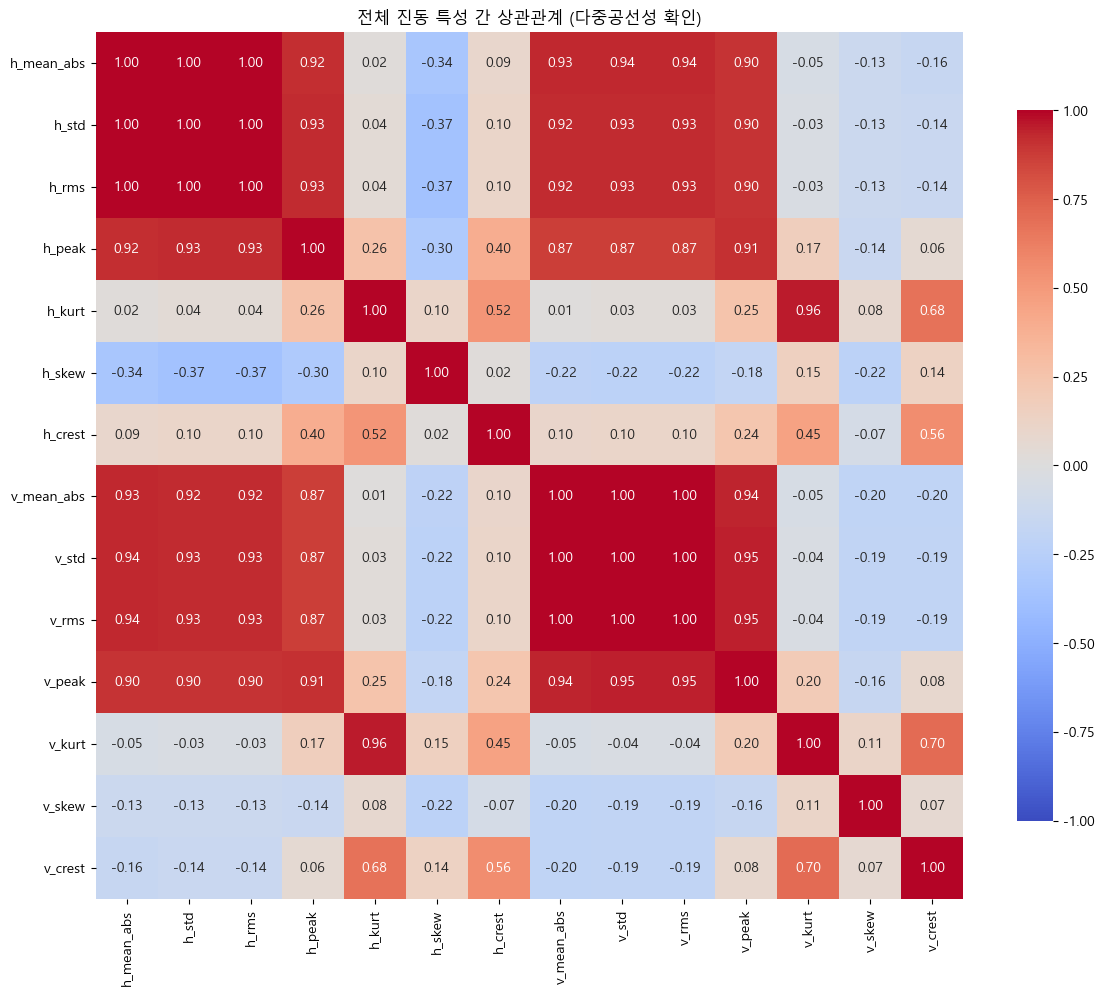

=== '크기' 계열끼리의 상관 (다중공선성) ===
            h_mean_abs  h_std  h_rms  h_peak  v_mean_abs  v_std  v_rms  v_peak
h_mean_abs        1.00   1.00   1.00    0.92        0.93   0.94   0.94    0.90
h_std             1.00   1.00   1.00    0.93        0.92   0.93   0.93    0.90
h_rms             1.00   1.00   1.00    0.93        0.92   0.93   0.93    0.90
h_peak            0.92   0.93   0.93    1.00        0.87   0.87   0.87    0.91
v_mean_abs        0.93   0.92   0.92    0.87        1.00   1.00   1.00    0.94
v_std             0.94   0.93   0.93    0.87        1.00   1.00   1.00    0.95
v_rms             0.94   0.93   0.93    0.87        1.00   1.00   1.00    0.95
v_peak            0.90   0.90   0.90    0.91        0.94   0.95   0.95    1.00


In [6]:
# 5. EDA-수치형 히트맵

# 먼저 모든 진동 특성(수평 h_, 수직 v_)을 펼쳐 상관관계를 확인한다
feat_cols = [c for c in df.columns if c.startswith(('h_', 'v_'))]

corr = df[feat_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8})
plt.title('전체 진동 특성 간 상관관계 (다중공선성 확인)')
plt.tight_layout()
plt.show()

# 크기 계열이 얼마나 뭉치는지 수치로 확인
size_group = ['h_mean_abs', 'h_std', 'h_rms', 'h_peak',
              'v_mean_abs', 'v_std', 'v_rms', 'v_peak']
print("=== '크기' 계열끼리의 상관 (다중공선성) ===")
print(df[size_group].corr().round(2))

In [9]:
# 6. 모델 3종 비교 (로지스틱 → 결정트리 → 랜덤포레스트)

models = {
    '로지스틱회귀':  make_pipeline(StandardScaler(), LogisticRegression()),  # 로지스틱만 스케일
    '결정트리':     DecisionTreeClassifier(random_state=42),
    '랜덤포레스트':  RandomForestClassifier(n_estimators=100, random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append({
        '모델': name,
        '정확도':  accuracy_score(y_test, pred),
        '정밀도':  precision_score(y_test, pred, zero_division=0),
        '재현율':  recall_score(y_test, pred, zero_division=0),
        'F1':     f1_score(y_test, pred, zero_division=0),
    })

print(pd.DataFrame(results).to_string(index=False))

    모델      정확도      정밀도      재현율       F1
로지스틱회귀 0.885350 0.990909 0.865079 0.923729
  결정트리 0.955414 0.991736 0.952381 0.971660
랜덤포레스트 0.993631 0.992126 1.000000 0.996047


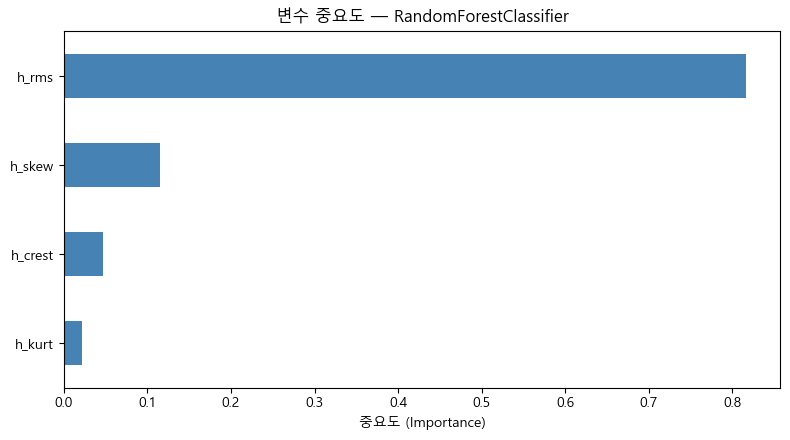

=== 변수 중요도 (큰 순) ===
h_rms      0.817
h_skew     0.115
h_crest    0.046
h_kurt     0.022
dtype: float64


In [ ]:
# 7. 변수 중요도 (기본 RandomForestClassifier)

features = ['h_rms', 'h_kurt', 'h_skew', 'h_crest']

# 기본 RF로 학습 (튜닝 전, 전체 데이터)
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(df[features], df['degraded'])

# 중요도 정리
imp = pd.Series(rf_base.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8, 4.5))
imp.plot(kind='barh', color='steelblue')
plt.xlabel('중요도 (Importance)')
plt.title('변수 중요도 — RandomForestClassifier')
plt.tight_layout()
plt.show()

print("=== 변수 중요도 (큰 순) ===")
print(imp.sort_values(ascending=False).round(3))

In [ ]:
# 8. RandomForestClassifier 최적화 (GridSearchCV)

features = ['h_rms', 'h_kurt', 'h_skew', 'h_crest']
X = df[features]
y = df['degraded']
groups = df['bearing']

param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
}

# 검증도 베어링 단위(누수 방지) = slice 원칙을 GridSearch에 적용
gkf = GroupKFold(n_splits=5)

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=gkf, scoring='f1', n_jobs=-1   # 열화 탐지라 f1
)
grid.fit(X, y, groups=groups)

print("최적 하이퍼파라미터:", grid.best_params_)
print("최적 교차검증 F1: %.3f" % grid.best_score_)

best_rf = grid.best_estimator_     # 다음 셀(혼동행렬/저장)에서 사용

최적 하이퍼파라미터: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
최적 교차검증 F1: 0.926


정확도 : 0.994
정밀도 : 0.992
재현율 : 1.0
F1     : 0.996


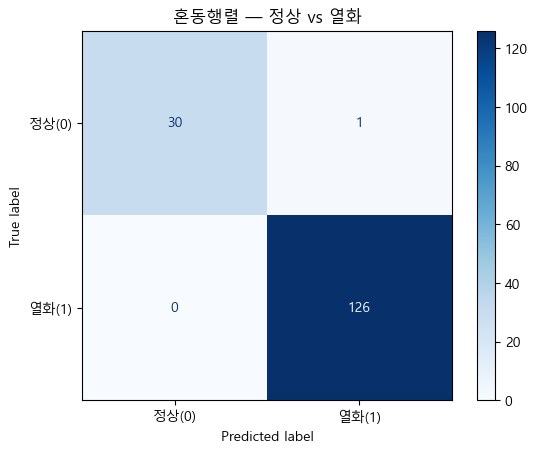

In [ ]:
# 9. 최종 모델 평가 (혼동행렬 + 전체 지표)

# 시간순 slice (셀3 기준 그대로), best_rf로 평가
train = df[df['life_progress'] < 75]
test  = df[df['life_progress'] >= 75]
best_rf.fit(train[features], train['degraded'])
pred = best_rf.predict(test[features])

print("정확도 :", round(accuracy_score(test['degraded'], pred), 3))
print("정밀도 :", round(precision_score(test['degraded'], pred, zero_division=0), 3))
print("재현율 :", round(recall_score(test['degraded'], pred, zero_division=0), 3))
print("F1     :", round(f1_score(test['degraded'], pred, zero_division=0), 3))

cm = confusion_matrix(test['degraded'], pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['정상(0)', '열화(1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('혼동행렬 — 정상 vs 열화')
plt.show()

In [11]:
# 9-1. Classification Report (지표 종합표)

print(classification_report(
    test['degraded'], pred,
    target_names=['정상(0)', '열화(1)'],
    digits=3
))

              precision    recall  f1-score   support

       정상(0)      1.000     0.968     0.984        31
       열화(1)      0.992     1.000     0.996       126

    accuracy                          0.994       157
   macro avg      0.996     0.984     0.990       157
weighted avg      0.994     0.994     0.994       157



In [ ]:
# 10. 모델 저장

# best_rf를 전체 데이터로 최종 학습 후 저장 (배포용은 가진 데이터 다 씀)
features = ['h_rms', 'h_kurt', 'h_skew', 'h_crest']
best_rf.fit(df[features], df['degraded'])

joblib.dump(best_rf, 'bearing_model.pkl')
print("저장 완료: bearing_model.pkl")

# 임계값 기준(베어링 초기 RMS)도 같이 저장 — Streamlit에서 입력값 판단에 필요할 수 있음
print("학습에 쓴 특성:", features)

# features min/max 
df[features].describe()

저장 완료: bearing_model.pkl
학습에 쓴 특성: ['h_rms', 'h_kurt', 'h_skew', 'h_crest']


,h_rms,h_kurt,h_skew,h_crest
count,616.000000,616.000000,616.000000,616.000000
mean,1.445736,0.984792,-0.023163,6.144914
std,1.312309,5.733043,0.090236,1.977505
min,0.370712,-0.341081,-0.521022,3.572866
25%,0.517328,0.053511,-0.041676,4.525700
50%,0.787906,0.473199,0.001201,5.809790
75%,2.466962,1.302597,0.020780,7.209485
max,9.216745,141.459260,0.309126,26.517287


In [ ]:
# 11. Streamlit 대시보드용 그림 저장

# (1) 열화곡선
plt.figure(figsize=(9, 5))
for b, g in df.groupby('bearing'):
    plt.plot(g['op_minute'], g['h_rms'], label=b)
plt.xlabel('경과시간(분)'); plt.ylabel('수평 RMS'); plt.title('베어링별 진동 RMS 추이')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('fig_rms.png', dpi=120); plt.close()

# (2) 상관관계 히트맵
plt.figure(figsize=(5, 4))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True)
plt.title('최종 특성 상관관계'); plt.tight_layout()
plt.savefig('fig_corr.png', dpi=120); plt.close()

# (3) 변수 중요도
imp = pd.Series(best_rf.feature_importances_, index=features).sort_values()
plt.figure(figsize=(7, 4))
imp.plot(kind='barh', color='steelblue')
plt.xlabel('중요도'); plt.title('변수 중요도'); plt.tight_layout()
plt.savefig('fig_importance.png', dpi=120); plt.close()

# (4) 혼동행렬
train = df[df['life_progress'] < 75]; test = df[df['life_progress'] >= 75]
best_rf.fit(train[features], train['degraded'])
pred = best_rf.predict(test[features])
cm = confusion_matrix(test['degraded'], pred)
ConfusionMatrixDisplay(cm, display_labels=['정상', '열화']).plot(cmap='Blues', values_format='d')
plt.title('혼동행렬'); plt.tight_layout()
plt.savefig('fig_cm.png', dpi=120); plt.close()

# 모델은 전체 데이터로 재학습 후 저장
best_rf.fit(df[features], df['degraded'])
joblib.dump(best_rf, 'bearing_model.pkl')
print('그림 4개 + 모델 저장 완료')

그림 4개 + 모델 저장 완료
